# Tema 5: Soluciones de Ecuaciones

## 1. Sistemas de ecuaciones lineales

###  1.1 Elim. Gaussiana con pivote

In [2]:
# Sust. hacia atrás
import numpy as np

def sust_atras(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N-1, -1, -1):
        x[i] = B[i]
        for n in range(i+1, N):
            x[i] -= A[i, n]*x[n]
        x[i] /= d[i]
    return x

In [3]:
# Sust. hacia delante
import numpy as np

def sust_adelant(A, B):
    N = len(B)
    x = np.empty_like(B)
    d = np.diag(A)
    
    for i in range(N):
        x[i] = B[i]
        for n in range(i):
            x[i]-=A[i,n]*x[n]
        x[i] /= d[i]
    return x

In [4]:
# Algoritmo para hacer matriz triang. sup. con pivote

import numpy as np
def make_triang_sup(AB):
    # 1. Ubico elemento máximo y pivoto
    # 2. Divido por pivote toda la fila
    # 3. Resto en cascada multiplicando por la cabeza de cada fila
    
    N = len(AB)
    for i in range(N): # Por cada fila
        col = AB[i:, i] # No puedo tomar como pivote de la fila 2 algo de la fila 1
        pivote = np.max(col)
        ind = np.where(col==pivote)[0][0] + i # No puedo tener en cuenta las filas superiores
        
        # Una vez ubicado el pivote, pivoto fila actual por la de interés
        AB[i,:], AB[ind, :] = AB[ind, :].copy(), AB[i, :].copy()
        
        # Ahora divido por el pivote de la fila
        AB[i,i:] /= pivote
        
        # Finalmente, multiplico por cabeza de cada fila y resto
        for j in range(i+1, N):
            head = AB[j, i]
            AB[j,i:] -= head*AB[i,i:] # Solo resto aquel subconjunto de las filas que es no nulo
        
    return AB
    
A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
B=np.array([-4,3,9,7],float)

AB = np.column_stack((A, B))

triang = make_triang_sup(AB)

A = triang[:,:-1]
B = triang[:,-1]

print(sust_atras(A, B))

[ 2. -1. -2.  1.]


In [5]:
# Gauss completo con pivote

def solveGauss(A, B):
    AB = np.column_stack((A, B))
    triang = make_triang_sup(AB)
    
    A = AB[:,:-1]
    B = AB[:,-1]
    
    return sust_atras(A, B)

A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
B=np.array([-4,3,9,7],float)

print(solveGauss(A, B))

[ 2. -1. -2.  1.]


### 1.1.1 Optimización para matrices tridiagonales

In [4]:
# programa que optimiza la eliminación gussiana para matrices tridiagonales.

def tridiagonal_gaussian(A,v):
    N=len(v)
    
    for i in range(N-1):
        # 1. Dividimos la fila por su primer elemento
        #    sólo tenemos que hacerlo con el elemento a la derecha
        #    no hace falta que mandemos el elmento A[i,i] a 1-
        #    Es suficiente con tenerlo en cuenta al hacer la eliminación hacía atrás.
        

        A[i,i+1]/=A[i,i]    
        v[i]/=A[i,i]
        
        # 2. Le sustraemos a la fila i+1 la fila i multiplicada por A[i+1,i]
        
        A[i+1,i+1]-=A[i+1,i]*A[i,i+1]   # no hace falta mandar el elmento A[i+1,i] a cero
        v[i+1]-=A[i+1,i]*v[i]           # es suficiente asumirlo 
                                        # en la sustitución hacía atrás
   
    # 3. Nuestro for va hasta N-2, sólo nos falta operar sobre el último elemento de V
    v[N-1]/=A[N-1,N-1]

    # 4. Sustitución hacia atrás.
    x=zeros(N,float)
    x[N-1]=v[N-1]
    for i in range(N-2,-1,-1):
        x[i]=v[i]-A[i,i+1]*x[i+1]
    return x

### 1.2 LU con pivote

In [95]:
import numpy as np

def LUP(A):
    N = len(A)
    U = np.copy(A)
    L = np.zeros_like(A)
    P = np.eye(N)
    
    for i in range(N): # Se trata ahora de hacer U triangular superior
        L[i:,i] = U[i:,i]
        
        col = U[i:, i] # No puedo tomar como pivote de la fila 2 algo de la fila 1
        pivote = np.max(col)
        ind = np.where(col==pivote)[0][0] + i # No puedo tener en cuenta las filas superiores
        
        # Una vez ubicado el pivote, pivoto fila actual por la de interés
        U[i,:], U[ind, :] = U[ind, :].copy(), U[i, :].copy()
        L[i,:], L[ind, :] = L[ind, :].copy(), L[i, :].copy()
        P[i,:], P[ind, :] = P[ind, :].copy(), P[i, :].copy()
        
        # Ahora divido por el pivote de la fila
        U[i, i:] /= pivote
        
        # Finalmente, multiplico por cabeza de cada fila y resto
        for j in range(i+1, N):
            head = U[j, i]
            U[j,i:] -= head*U[i, i:] # Solo resto aquel subconjunto de las filas que es no nulo
        
    return L, U, P

def solveLU(L, U, PB):
    # 1. Ly = PB (adelant.)
    # 2. Ux = y (atras.)
    
    y = sust_adelant(L, PB)
    x = sust_atras(U, y)
    
    return x

A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)
B=np.array([-4,3,9,7],float)

print(A)
L, U, P = LUP(A)

print(solveLU(L, U, np.dot(P, B)))

[[ 2.  1.  4.  1.]
 [ 3.  4. -1. -1.]
 [ 1. -4.  1.  5.]
 [ 2. -2.  1.  3.]]
[ 2. -1. -2.  1.]


## 2. Inversión de matrices

In [15]:
# AA^-1 = I y resuelvo por columnas (con LU me ahorro tener que operar sobre A N veces)

A=np.array([[2,1,4,1],[3,4,-1,-1],[1,-4,1,5],[2,-2,1,3]],float)

L, U, P = LUP(A)

inv = solveLU(L, U, P) # PB = P·I = P



## 3. Diagonalización (QR)

In [17]:
# Factorización QR de una matriz
import numpy as np

def QR_fact(A):
    N = len(A)
    Q = np.zeros((N,N), float)
    R = np.zeros((N,N), float)
    U = np.zeros((N,N), float)
    
    for m in range(N):
        U[:,m] = A[:,m]
        for i in range(m): # En la primera iteración de i no entra
            R[i,m] = np.dot(Q[:,i], A[:,m])
            U[:,m] -= R[i,m]*Q[:,i]
        R[m,m] = np.linalg.norm(U[:,m])
        Q[:,m] = U[:,m]/R[m,m]
    
    return Q,R

A = np.array([[1, 4, 8, 4], [4, 2, 3, 7], [8, 3, 6, 9], [4, 7, 9, 2]], float)

Q, R = QR_fact(A)

In [19]:
# Lista de autovalores de una matriz

def eigvals(A, tol): # solo autovalores, recortamos operaciones ignorando V
    err = 1.0
    mask = ~np.eye(A.shape[0],dtype=bool)
    
    while err > tol:
        Q, R = QR_fact(A)
        A1 = np.dot(R, Q)
        
        err = np.max(np.abs(A1[mask]-A[mask]))
        
        A = A1
    return np.diag(A)

[21. -8. -3.  1.]


In [25]:
# Autovalores y autovectores

def eig(A, tol):
    N = len(A)
    V = np.eye(N)
    
    err = 1.0
    mask = ~np.eye(A.shape[0],dtype=bool)
    
    while err > tol:
        Q, R = QR_fact(A)
        V = np.dot(V, Q)
        
        A1 = np.dot(R, Q)
        
        err = np.max(np.abs(A1[mask]-A[mask]))
        
        A = A1
    return np.diag(A), V

A = np.array([[1, 4, 8, 4], [4, 2, 3, 7], [8, 3, 6, 9], [4, 7, 9, 2]], float)

eigvals, V = eig(A, 10**(-6))

[[ 1.07555842e-07  1.38400827e-07  1.03937268e-08 -5.33166516e-09]
 [-1.21000307e-07  1.13356010e-07 -1.50252362e-08 -1.77722848e-09]
 [-1.47889274e-07  1.68978067e-07 -8.29328217e-09  1.77720361e-09]
 [ 1.74778235e-07  1.36288937e-07  1.22246138e-08  3.55442586e-09]]


## 4. Ecuaciones no lineales

### 4.1 Punto fijo / relajación, $f(x)=x$

In [2]:
import numpy as np

def punto_fijo(f, x0, tol):
    err = 1.0
    while err > tol:
        x1 = f(x0)
        err = np.abs(x1-x0)
        x0=x1
    return x1

f = lambda x: x/2

punto_fijo(f, 0.3,1e-6)

5.7220458984375e-07

In [ ]:
# Punto fijo para minimizar (grad=0, por eso añado X. De lo contrario, no lo haría. También
# podía haber metido +1 en cada función y sería un ej. normal de punto fijo, con F(X)=X)
import numpy as np

f1 = lambda x, y: -2*np.sin(x**2+y**2)*x
f2 = lambda x, y: -2*np.sin(x**2+y**2)*y

def F(X):
    x, y = X
    return np.array([f1(x, y), f2(x, y)])+X

def punto_fijo_Nvar(X0, tol):
    err = 1.0
    cont=0
    while cont < 6000:
        cont+=1
        X1 = F(X0)
        err = np.linalg.norm(X1-X0)
        X0=X1
    return X1

punto_fijo_Nvar([1,1], 10**(-10))

### 4.2 Bisección (falla si la función se iguala a 0 en un segmento (e.g: asíntota horizontal))

In [30]:
import numpy as np

def biseccion(f, a, b, tol):
    err = 1.0
    
    while err > tol:
        x_med = (a+b)/2
        if f(a)*f(x_med) > 0: # Seguimos estando en la parte de a
            a = x_med
        else:
            b = x_med
        err = np.abs(b-a)
        
    return (a+b)/2

f = lambda x: x+0.5

biseccion(f, -1,1,10**(-6))

-0.5000004768371582

### 4.3 Newton-Raphson

In [63]:
import numpy as np

def newton_raphson(f, der, x0, tol):
    err = 1.0
    
    while err > tol:
        x1 = x0-f(x0)/der(x0)
        err = np.abs(x1-x0)
        x0 = x1
    return x0

In [37]:
# Newton-Raphson en varias variables (sistemas de ecuaciones no lineales)

import numpy as np

f1 = lambda x, y: 2*x
f2 = lambda x, y: 2*y

J_1x = lambda x, y: 2
J_1y = lambda x, y: 0
J_2x = lambda x, y: 0
J_2y = lambda x, y: 2

def F(r):
    x, y = r
    return np.array([f1(x, y), f2(x, y)], float)

def J(r):
    x, y = r
    return np.array([[J_1x(x, y), J_1y(x, y)], [J_2x(x, y), J_2y(x, y)]], float)

def newton_raphson_Nvar(X0, tol):
    # Resolvemos el sistema lineal: JD_x = F. No podemos usar LU para actuar sobre J una sola vez porque hay que recalcularlo para cada x1
    err = 1.0
    
    while err > tol:
        J0 = J(X0)
        F0 = F(X0)
        
        Dx = solveGauss(J0, F0)
        X1 = X0-Dx
        
        err = np.max(np.abs(X1-X0))
        X0=X1
        
    return X1

f = lambda x: x**2+y**2

newton_raphson_Nvar([1,1], 10**(-6))

array([0., 0.])

### 4.4 Secante (Newton-Raphson con derivada numérica)

In [31]:
import numpy as np

def secante(f, x0, tol):
    err = 1.0
    h = 10**(-5)

    while err > tol:
        der = (f(x0+h/2)-f(x0-h/2))/h
        x1 = x0-f(x0)/der
        err = np.abs(x1-x0)
        x0=x1
    return x0

f = lambda x: x**3

secante(f, 0.5, 10**(-6))

2.8126253935108973e-06

## 5. Minimización

### 5.1 Gradiente nulo

Plantear sistema de ecuaciones que sale de $\vec \nabla f = \vec 0$ y resolver con tu método preferido. Es un sistema de ecuaciones (no) lineales, así que usa (Gauss) Newton-Raphson

### 5.2 Razón Áurea

In [1]:
import numpy as np

def razon_aurea(f, x1, x4, tol):
    z = (1+np.sqrt(5))/2
    
    x2 = x4 - (x4-x1)/z
    x3 = x1 + (x4-x1)/z
    
    err = 1.0
    
    while err > tol:
        if f(x2) < f(x3): # Vamos en el buen camino si vamos hacia la izq.
            x4 = x3
            x3 = x2
            x2 = x4 - (x4-x1)/z
        else:
            x1 = x2
            x2 = x3
            x3 = x1 + (x4-x1)/z
        err = np.abs(x4-x1)
    return (x1+x4)/2

f = lambda x: x**2
print(razon_aurea(f, -1,1,10**(-6)))

-2.0530310225099582e-07


In [ ]:
import matplotlib.pyplot as plt



### 5.3 Newton-Gauss (usar Newton-Raphson para hallar mínimos, porque es hallar raíces de función derivada)

Aplicar Newton-Raphson para $f'(x)=0$ o bien Newton-Raphson en varias variables para $\vec\nabla f=\vec 0$

### 5.4 Gradiente descendente (muchísimo más eficientes los que tienen búsqueda lineal (paso optimizado en cada iteración))

In [75]:
import numpy as np

def grad_descend(der, gamma, x0, tol):
    cont=0
    err = 1.0
    while err > tol:
        cont+=1
        x1 = x0 - gamma*der(x0)
        err = np.abs(x1-x0)
        x0 = x1
    print(cont)
    return x0

def grad_descend_opt(f, der, x0, tol): # Es como máxima pendiente en 1 dim.
    cont=0
    err = 1.0
    while err > tol:
        cont+=1
        g = lambda alpha: f(x0+alpha*der(x0))
        alpha_opt = razon_aurea(g, -1,1, 1e-6)
        x1 = x0+alpha_opt*der(x0)
        err = np.abs(x1-x0)
        x0=x1
    print(cont)
    return x1

# ¿Y si no conocemos la derivada de la función? --> Numéricamente

def grad_descend_sin_der(f, gamma, x0, tol):
    cont=0
    err = 1.0
    h = 10**(-5)
    while err > tol:
        cont+=1
        der = (f(x0+h/2)-f(x0-h/2))/h
        x1 = x0 - gamma*der
        err = np.abs(x1-x0)
        x0 = x1
    print(cont)
    return x0

def grad_descend_sin_der_opt(f, x0, tol):
    cont=0
    err = 1.0
    h=1e-5
    while err > tol:
        cont+=1
        der = (f(x0+h/2)-f(x0-h/2))/h
        g = lambda alpha: f(x0+alpha*der)
        alpha_opt = razon_aurea(g, -1,1, 1e-6)
        x1 = x0+alpha_opt*der
        err = np.abs(x1-x0)
        x0=x1
    print(cont)
    return x1

f = lambda x: -np.cos(x)
der = lambda x: np.sin(x)

112
8.317202592422746e-06
4
1.0536709006997108e-08


### 5.5 Máxima pendiente

In [40]:
import numpy as np

def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-5)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x, der_y])

def max_pendiente(f, X0, tol):
    err = 1.0

    while err > tol:
        v = grad(f, X0) # Dir de mínima pendiente hacia abajo para hallar el mínimo
        # Ahora avanzo un paso en esta dirección
        mod = np.linalg.norm(v)
        
        g = lambda alpha: f(X0[0]+alpha*v[0]/mod, X0[1]+alpha*v[1]/mod) # Encuentro el paso que antes me garantiza la minimización (convergencia)
        
        alpha_opt = razon_aurea(g, -3,3,10**(-6))
        
        X1 = X0+alpha_opt*v/mod
        err = np.linalg.norm(X1-X0)

        X0=X1
    return X1

f = lambda x, y: np.sin(x**2+y**2)
max_pendiente(f, [1,1], 10**(-6))

array([-1.40180675e-07, -1.40180675e-07])

### 5.6 Gradiente conjugado

In [3]:
import numpy as np

def grad(f, X0): # Evalúa el gradiente en un punto
    x0, y0 = X0
    h = 10**(-5)
    
    der_x = (f(x0+h/2, y0)-f(x0-h/2, y0))/h
    der_y = (f(x0, y0+h/2)-f(x0, y0-h/2))/h
    
    return np.array([der_x, der_y])


def grad_conj(f, X0, tol):
    err = 1.0
    v = -grad(f, X0)
    
    while err > tol:
        mod = np.linalg.norm(v)
        
        g = lambda alpha: f(X0[0]+alpha*v[0]/mod, X0[1]+alpha*v[1]/mod)
        
        alpha_opt = razon_aurea(g, -3,3,1e-6)

        X1 = X0+alpha_opt*v/mod
        
        err = np.linalg.norm(X1-X0)
        
        grad_0 = grad(f, X0)
        grad_1 = grad(f, X1)
        
        beta = np.linalg.norm(grad_1)/np.linalg.norm(grad_0)
        v = -grad_1+beta*v/mod
        
        X0=X1
    return X1

# def grad_conj(X0, tol): # Si quieres MÁXIMO, le cambias el signo

#     err = 1.0
    
#     alpha=10**(-4)
#     D = -grad(f, X0)

#     while err > tol:
        
        
#         X1 = lambda alpha: X0+alpha*D

#         err = lambda alpha: np.linalg.norm(X1(alpha)-X0)
        
#         alpha = razon_aurea(err, 0, 1,10**(-4))
        
#         X1, err = X1(alpha), err(alpha)
        
#         grad_0 = grad(f, X0)
#         grad_1 = grad(f, X1)
        
#         beta = np.linalg.norm(grad_1)/np.linalg.norm(grad_0) # Solo sirve para calcular la nueva dirección a partir de la anterior
        
#         D = -grad_1+beta*D
        
#         X0=X1
   
#     return X1

f = lambda x, y: np.exp(x**2+y**2)
grad_conj(f, [1,1], 10**(-6))

NameError: name 'razon_aurea' is not defined

# Tema 7: EDOs

## Sin adaptar

### 1. Euler

$$x(t+h) = x(t)+hf(x(t), t)$$

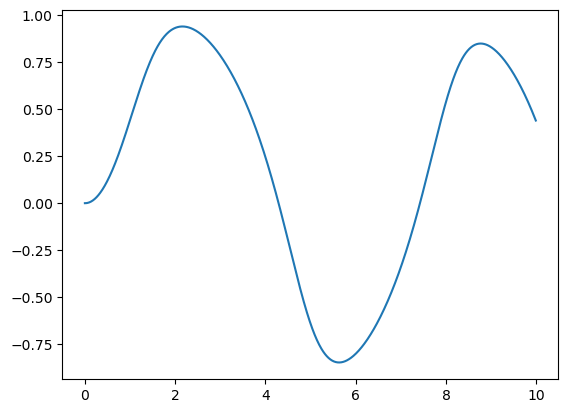

In [152]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f = lambda x, t: -x**3+np.sin(t)

a=0
b=10
N=1000
h = (b-a)/N

tp = np.arange(a,b,h)

x=0

################################################

xp = []

for t in tp:
    xp.append(x)
    
    x+= h*f(x, t)

plt.plot(tp, xp)
plt.show()

### 2. RK2 / Punto medio

$$x(t+h/2)=x(t)+\frac{h}{2}f[x(t), t]$$
$$x(t+h)=x(t)+hf[x(t+h/2), t+h/2]$$

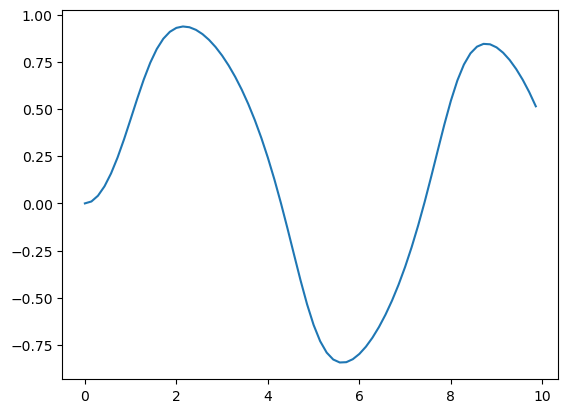

In [160]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f = lambda x, t: -x**3+np.sin(t)

a=0
b=10
N=70
h = (b-a)/N

tp = np.arange(a,b,h)

x=0

################################################

xp = []

for t in tp:
    xp.append(x)
    
    # Punto medio
    x_med = x+h/2*f(x,t)
    
    x += h*f(x_med, t+h/2)
    
plt.plot(tp, xp)
plt.show()

### 3. RK4

$$k_1 = hf(x,t)$$
$$k_2 = hf(x+k_1/2, t+h/2) $$
$$k_3 = hf(x+k_2/2, t+h/2)$$
$$k_4 = hf(x+k_3,t+h)$$

Y finalmente calculamos $x(t+h)$ apoyándonos en todos estos puntos intermedios, de la forma:

$$x(t+h)=x(t)+\frac{1}{6}(k_1+2k_2+2k_3+k_4)$$

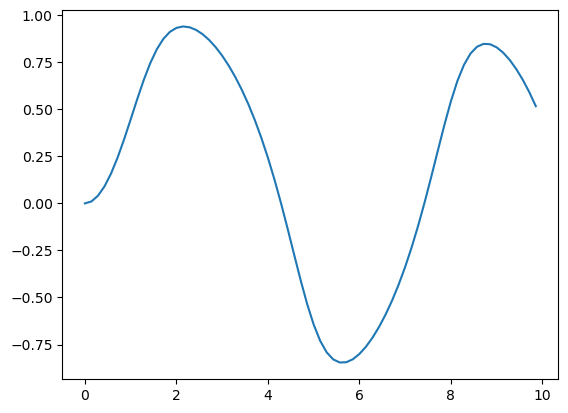

In [161]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f = lambda x, t: -x**3+np.sin(t)

a=0
b=10
N=70
h = (b-a)/N

tp = np.arange(a,b,h)

x=0

################################################

xp = []

for t in tp:
    xp.append(x)
    
    k1 = h*f(x, t)
    k2 = h*f(x+k1/2, t+h/2)
    k3 = h*f(x+k2/2, t+h/2)
    k4 = h*f(x+k3, t+h)
    
    x+= 1/6*(k1+2*k2+2*k3+k4)
    
plt.plot(tp, xp)
plt.show()

## Multipaso

### 1. Salto de la rana O(h^3)

**Primer paso:** $x(t+h/2)=x(t)+\frac{h}{2}f[x(t), t]$

**Pasos de h entero:** $x(t+h)=x(t)+hf[x(t+h/2), t+h/2]$

**Pasos de h semientero:** $x(t+3h/2)=x(t+h/2)+hf[x(t+h), t+h]$

Fíjate en que los x de paso entero y semientero dependen uno del otro

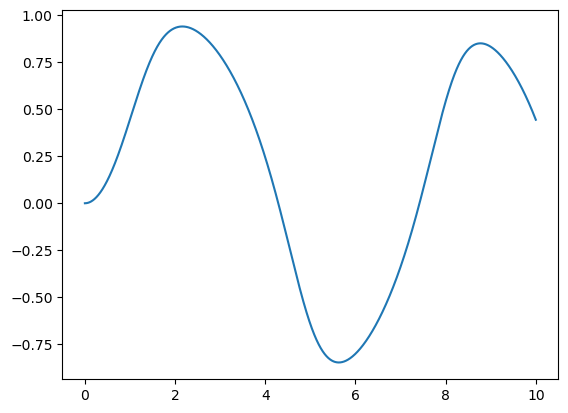

In [8]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f = lambda x, t: -x**3+np.sin(t)

a=0
b=10
N=10000
h = (b-a)/N

tp = np.arange(a, b, h)
x=0

################################################

xp = []

x_mitad = x+h/2*f(x, a)

for t in tp:
    xp.append(x)
    
    x+=h*f(x_mitad, t+h/2)
    x_mitad+=h*f(x, t+h)

plt.plot(tp, xp)
plt.show()

### 2. Verlet

**Nota:** solo vale para sistemas de 2 ecuaciones en los que la primera ec. dependa de una variable **pero no de la otra** y viceversa

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f_x = lambda v: v
f_v = lambda x, v: v**2-x-5

a=0
b=10
N=70
h = (b-a)/N

tp = np.arange(a,b,h)

x=0
v=
################################################

xp = []

# Primer paso del salto de la rana para colocar v donde quiero (en h's semienteros)
v = 

for t in tp:
    xp.append(x)
    
    

## Adaptados

### 1. RK4 (con extrapolación local) O(h^6) (más sencillo de programar con t<t_max)

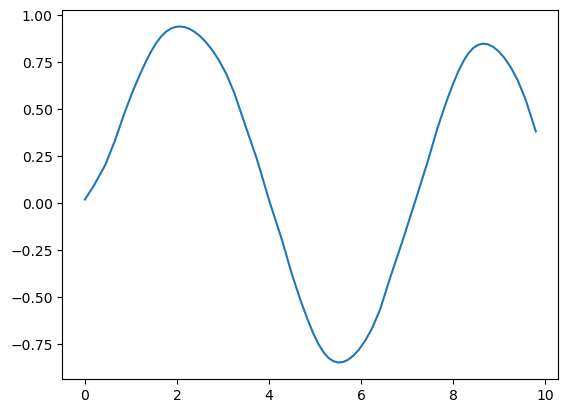

In [14]:
import numpy as np
import matplotlib.pyplot as plt

############# ME LO TIENEN QUE DAR #############
f = lambda x, t: -x**3+np.sin(t)

a=0
b=10
N=100
h = (b-a)/N

x=0

################################################

d=10**(-6)
xp = []

t=0
tp = []

while t<b:
    
    # Primero doy 2 pasos de longitud h
    k1 = h*f(x, t)
    k2 = h*f(x+k1/2, t+h/2)
    k3 = h*f(x+k2/2, t+h/2)
    k4 = h*f(x+k3, t+h)
    
    x1h = x+ 1/6*(k1+2*k2+2*k3+k4)
    
    k1 = h*f(x1h, t+h)
    k2 = h*f(x1h+k1/2, t+3*h/2)
    k3 = h*f(x1h+k2/2, t+3*h/2)
    k4 = h*f(x1h+k3, t+2*h)
    
    x11h = x1h + 1/6*(k1+2*k2+2*k3+k4)
    
    
    # Ahora doy un solo paso de longitud 2h
    k1 = 2*h*f(x, t)
    k2 = 2*h*f(x+k1/2, t+h)
    k3 = 2*h*f(x+k2/2, t+h)
    k4 = 2*h*f(x+k3, t+2*h)
    
    x2h = x+ 1/6*(k1+2*k2+2*k3+k4)
    
    
    # Comparativa
    
    p = 30*h*d/np.abs(x2h-x11h)
    h_obj = h*p**(1/4)
    
    if p>1:
        x=x11h + 1/15*(x11h-x2h)
        xp.append(x)
        
        tp.append(t)
        
        t+=2*h
        if p==np.inf:
            h*=2
        else:
            h = min(2*h, h_obj)
        
    else:
         h=h_obj
            
plt.plot(tp, xp)
plt.show()

## Sistemas de EDOs

## Cambios de variable para rangos infinitos